# Trabajo Practico N° 3

## Ejercicio 3.1  
*(Recordar el Ejercicio 2.3)*

Supongamos que tenemos un **dataset mezcla de dos grupos aleatorios bidimensionales**, cada uno con:

- 100 observaciones  
- Un **centroide**  
- Una **matriz de covarianza**

**Tip:** reutilizar el código de *Naive Bayes* visto para detección de *outliers*.

---

### Objetivo

1. Construir un **clasificador K-NN**.  
2. Evaluar su desempeño mediante:
   - Exactitud (*accuracy*)
   - Precisión (*precision*)
   - Medida F (*f-measure*)

---

### Configuración inicial

- Dataset de entrenamiento:
  
$$
N = 100 \quad (50 + 50)
$$

- Número de vecinos:

$$
k = 10
$$

- Validación: usar el **resto del dataset** como conjunto de prueba.

---

### Experimentos a realizar

- Variar el tamaño del conjunto de entrenamiento:

$$
N \in \{50,\;100,\;150,\;\dots\}
$$

- Probar distintos valores de:

$$
k \in \{1,\;3,\;5,\;10,\;15\}
$$

- Modificar:
  - Los **centroides** de las clases  
  - Las **matrices de covarianza**

---

### Opcional

> ¿Cambia significativamente el desempeño del clasificador si el dataset tiene **más dimensiones**?


In [1]:
# Import libraries
%matplotlib inline

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# Creamos dataset
mu_A = [22, 2]     # centro de A
sigma_A = [3, 1]  # dispersión de A

mu_B = [33, 3]     # centro de B
sigma_B = [4, 1]   # dispersión de B

N = 100

rng = np.random.default_rng(42)

# Clase A
XA = rng.normal(loc=mu_A, scale=sigma_A, size=(N, 2))
XA = np.rint(XA).astype(int)   # redondear a enteros

# Clase B
XB = rng.normal(loc=mu_B, scale=sigma_B, size=(N, 2))
XB = np.rint(XB).astype(int)

data = []

for x, y in XA:
    data.append(("A", x, y))

for x, y in XB:
    data.append(("B", x, y))

df = pd.DataFrame(data, columns=["target", "X", "Y"])

In [3]:
df

,target,X,Y
0,A,23,1
1,A,24,3
2,A,16,1
3,A,22,2
4,A,22,1
...,...,...,...
195,B,24,3
196,B,31,3
197,B,36,3
198,B,36,3


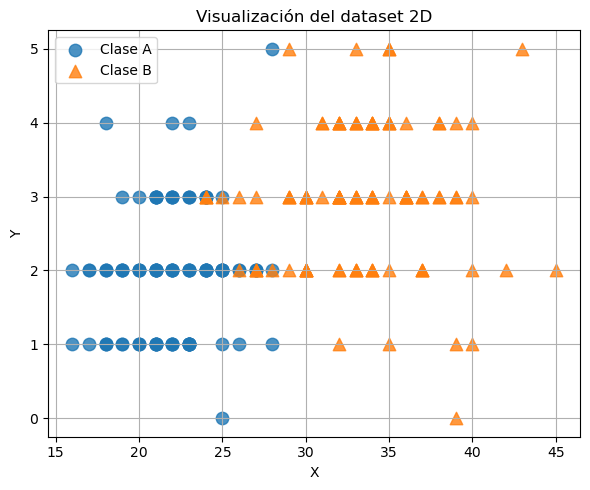

In [4]:
# Primero realizamos una visualización de datos

# Separar clases
df_A = df[df["target"] == "A"]
df_B = df[df["target"] == "B"]

plt.figure(figsize=(6, 5))

plt.scatter(df_A["X"], df_A["Y"], marker="o", s=80, label="Clase A", alpha=0.8)
plt.scatter(df_B["X"], df_B["Y"], marker="^", s=80, label="Clase B", alpha=0.8)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Visualización del dataset 2D")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
# Separamos features de target
X = df[["X", "Y"]].to_numpy()
y = df["target"].to_numpy() 

In [6]:
# Queremos train = 100 total => 50 de A y 50 de B (Clase balanceadas)
# El df tiene 200 total (100 A + 100 B), ponemos train_size=0.5 con stratify.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=100,          # N_train total
    random_state=42,
    stratify=y               # asegura 50/50 en train y 50/50 en test
)

In [7]:
# Pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=10))
])

In [8]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Probabilidad de la clase positiva ("B")
y_score = model.predict_proba(X_test)[:, 1]

In [9]:
# Métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label="B") # Se define B como clase "positiva"
f1 = f1_score(y_test, y_pred, pos_label="B")

In [10]:
print("Resultados KNN")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f} (positiva=B)")
print(f"F1-score : {f1:.4f} (positiva=B)\n")

print("Matriz de confusión (A,B):")
print(confusion_matrix(y_test, y_pred, labels=["A","B"]), "\n")

print("Classification report:")
print(classification_report(y_test, y_pred, labels=["A","B"]))

Resultados KNN
Accuracy : 0.9300
Precision: 1.0000 (positiva=B)
F1-score : 0.9247 (positiva=B)

Matriz de confusión (A,B):
[[50  0]
 [ 7 43]] 

Classification report:
              precision    recall  f1-score   support

           A       0.88      1.00      0.93        50
           B       1.00      0.86      0.92        50

    accuracy                           0.93       100
   macro avg       0.94      0.93      0.93       100
weighted avg       0.94      0.93      0.93       100



In [11]:
# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label="B")
auc = roc_auc_score(y_test, y_score)

print(f"AUC = {auc:.4f}")

AUC = 0.9784


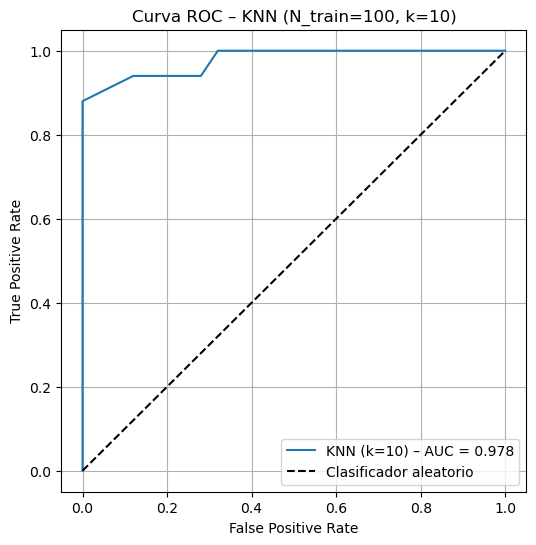

In [12]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"KNN (k=10) – AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC – KNN (N_train=100, k=10)")
plt.legend()
plt.grid(True)
plt.show()

### Conclusión  parcial

Para construir la curva ROC se utilizaron como scores las probabilidades estimadas por el clasificador K-NN para la clase B.
Variando el umbral de decisión sobre dichas probabilidades se obtuvo la relación entre TPR y FPR.

In [13]:
# Realizamos una función que nos permite probar parámetros y ver cual es mejor
def eval_knn_for(N_train=100, k=10, seed=42):
    
    X = df[["X", "Y"]].to_numpy()
    y = df["target"].to_numpy()

    # split estratificado con tamaño de train fijo
    sss = StratifiedShuffleSplit(n_splits=1, train_size=N_train, random_state=seed)
    (train_idx, test_idx) = next(sss.split(X, y))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "N_train": N_train,
        "k": k,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision(B)": precision_score(y_test, y_pred, pos_label="B"),
        "f1(B)": f1_score(y_test, y_pred, pos_label="B"),
    }

In [14]:
# Grid simple de experimentos
N_list = [i for i in range(20, 200, 20)] # tiene que ser <= 200
k_list = [1, 3, 5, 7, 10, 15, 21]

results = []
for N_train in N_list:
    for k in k_list:
        if k < (N_train / 2): # asegurarnos de que no tenga subajuste, apuntes de clase
            results.append(eval_knn_for(N_train=N_train, k=k, seed=42))

res_df = pd.DataFrame(results).sort_values(["N_train", "k"])
res_df

,N_train,k,accuracy,precision(B),f1(B)
0,20,1,0.900000,0.833333,0.909091
1,20,3,0.922222,0.872549,0.927083
2,20,5,0.933333,0.964286,0.931034
3,20,7,0.927778,0.987342,0.923077
4,40,1,0.937500,0.926829,0.938272
5,40,3,0.918750,0.885057,0.922156
6,40,5,0.918750,0.868132,0.923977
7,40,7,0.931250,0.972603,0.928105
8,40,10,0.912500,0.971429,0.906667
9,40,15,0.925000,0.972222,0.921053


In [15]:
best_by_N = (res_df.sort_values(["N_train", "f1(B)"], ascending=[True, False]).groupby("N_train").head(1))
best_by_N

,N_train,k,accuracy,precision(B),f1(B)
2,20,5,0.933333,0.964286,0.931034
4,40,1,0.937500,0.926829,0.938272
13,60,7,0.957143,0.984848,0.955882
20,80,7,0.950000,1.000000,0.947368
25,100,3,0.940000,1.000000,0.936170
36,120,15,0.962500,1.000000,0.961039
41,140,7,0.966667,1.000000,0.965517
47,160,5,0.975000,1.000000,0.974359
56,180,10,1.000000,1.000000,1.000000


## Conclusión

A partir de los resultados obtenidos por el clasificador **K-NN** se observa una clara dependencia del desempeño respecto del tamaño del conjunto de entrenamiento  
$N_{\text{train}}$ y del número de vecinos $k$.

---

### Influencia de $N_{\text{train}}$

- Para valores bajos de $N_{\text{train}}$ (20–40), el desempeño es **más inestable** y altamente sensible a la elección de $k$.
  - Con pocos datos, valores pequeños de $k$ tienden a **sobreajustar** (alta varianza).
  - Valores grandes de $k$ pueden introducir **subajuste**, diluyendo la información local.

- A medida que aumenta $N_{\text{train}}$ ($\ge 60$), se observa:
  - Un **incremento sostenido** de *accuracy* y *F1-score*.
  - **Menor variabilidad** frente a cambios en $k$.
  - **Mayor robustez estadística** del clasificador.

- Para $N_{\text{train}} \ge 140$, el modelo alcanza desempeños **cercanos al óptimo**, con *accuracy* y *F1* superiores a **0.96**, e incluso **clasificación perfecta** para  
  $N_{\text{train}} = 180$.

Esto indica que el problema es **bien separable** y que **K-NN se beneficia fuertemente de un mayor volumen de datos**.

---

### Influencia de $k$

- Para valores pequeños de $k$ (1–3):
  - El clasificador es **muy sensible al ruido**.
  - Se observan **fluctuaciones** en *precision* y *F1*, especialmente con pocos datos.

- Para valores intermedios de $k$ (5–10):
  - Se obtiene el **mejor compromiso bias–variance**.
  - Se maximizan *accuracy* y *F1* de forma **consistente** en casi todos los tamaños de entrenamiento.

- Para valores grandes de $k$ ($\ge 15$–$21$):
  - El rendimiento tiende a **estabilizarse**.
  - En datasets grandes no se observa degradación significativa.
  - En datasets pequeños puede aparecer una **leve pérdida de exactitud**.

En este problema, valores **intermedios de $k$ (≈ 5–10)** resultan los más adecuados, especialmente para tamaños de entrenamiento moderados.

---

### Métricas (Precision y F1)

- La *precision* para la clase **B** alcanza valores cercanos o iguales a **1.0** en muchos escenarios, lo que indica una **muy baja tasa de falsos positivos**.
- El *F1-score*, al combinar *precision* y *recall*, confirma que el clasificador mantiene un **equilibrio adecuado** entre detección y confiabilidad.
- El crecimiento coherente de *accuracy*, *precision* y *F1* refuerza la **consistencia y estabilidad** del modelo.


## Experimentos con cambios en centroide y varianza

In [16]:
def make_df(mu_A=(22,2), sigma_A=(3,1), mu_B=(33,3), sigma_B=(4,1), N=100, seed=42):
    
    rng = np.random.default_rng(seed)
    
    XA = rng.normal(loc=mu_A, scale=sigma_A, size=(N, 2))
    XB = rng.normal(loc=mu_B, scale=sigma_B, size=(N, 2))

    XA = np.rint(XA).astype(int)
    XB = np.rint(XB).astype(int)

    data = [("A", x, y) for x, y in XA] + [("B", x, y) for x, y in XB]
    
    return pd.DataFrame(data, columns=["target", "X", "Y"])

In [17]:
def experiment(muA, sigA, muB, sigB, N=100, N_train=100, k=10, seed=42, title="Dataset original"):
    
    df_local = make_df(muA, sigA, muB, sigB, N=N, seed=seed)

    df_A = df_local[df_local["target"] == "A"]
    df_B = df_local[df_local["target"] == "B"]
    
    plt.figure(figsize=(6, 5))
    
    plt.scatter(df_A["X"], df_A["Y"], marker="o", s=80, label="Clase A", alpha=0.8)
    plt.scatter(df_B["X"], df_B["Y"], marker="^", s=80, label="Clase B", alpha=0.8)
    
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Visualización del dataset 2D - {title}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    X = df_local[["X","Y"]].to_numpy()
    y = df_local["target"].to_numpy()

    sss = StratifiedShuffleSplit(n_splits=1, train_size=N_train, random_state=seed)
    train_idx, test_idx = next(sss.split(X, y))

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[test_idx])

    return {
        "muA": muA, "sigA": sigA, "muB": muB, "sigB": sigB,
        "accuracy": accuracy_score(y[test_idx], y_pred),
        "precision(B)": precision_score(y[test_idx], y_pred, pos_label="B"),
        "f1(B)": f1_score(y[test_idx], y_pred, pos_label="B"),
    }

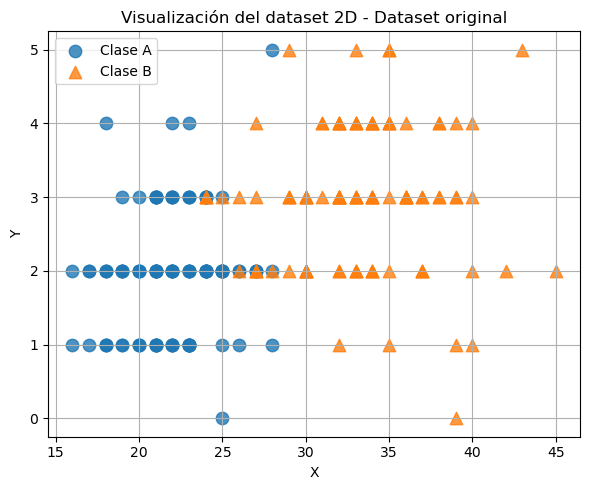

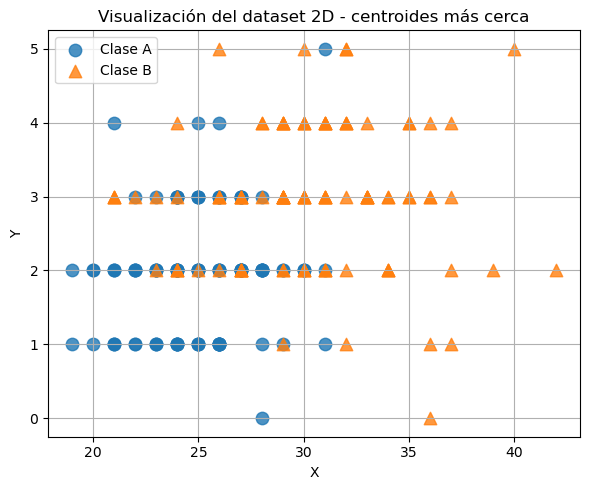

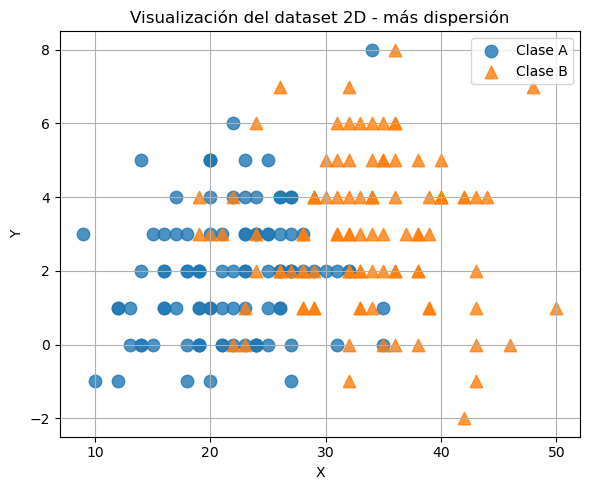

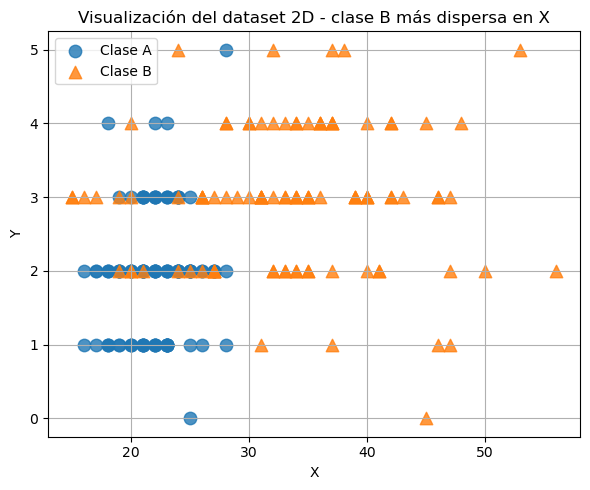

,muA,sigA,muB,sigB,accuracy,precision(B),f1(B)
0,"(22, 2)","(3, 1)","(33, 3)","(4, 1)",0.93,1.000000,0.924731
1,"(25, 2)","(3, 1)","(30, 3)","(4, 1)",0.84,0.886364,0.829787
2,"(22, 2)","(6, 2)","(33, 3)","(6, 2)",0.85,0.926829,0.835165
3,"(22, 2)","(3, 1)","(33, 3)","(8, 1)",0.90,1.000000,0.888889


In [18]:
exp_results = []
exp_results.append(experiment((22,2),(3,1), (33,3),(4,1), N=100, N_train=100, k=10))
exp_results.append(experiment((25,2),(3,1), (30,3),(4,1), N=100, N_train=100, k=10, title="centroides más cerca"))  # centroides más cerca
exp_results.append(experiment((22,2),(6,2), (33,3),(6,2), N=100, N_train=100, k=10, title="más dispersión"))  # más dispersión
exp_results.append(experiment((22,2),(3,1), (33,3),(8,1), N=100, N_train=100, k=10, title="clase B más dispersa en X"))  # clase B más dispersa en X

pd.DataFrame(exp_results)

# Conclusión parcial

A partir de los resultados obtenidos por el clasificador **K-NN**, al cambiar los centroides y dispersión, y teniendo en cuenta que en un principio el dataset tenía una "clara" separación, se puede observar:

1. Al *acercar* los centroides, los datos de ambas clases quedan más próximos entre sí, generando un mayor solapamiento. Como consecuencia, la tarea de *separar* las clases mediante un clasificador, más precisamente kNN se vuelve más **difícil**, reflejándose en una disminución del desempeño (accuracy, precision y F1-score).

2. Al aumentar la **dispersión** de las clases, incluso manteniendo los centroides fijos, se incrementa la superposición entre ambas distribuciones. Esto introduce mayor ambigüedad en la clasificación, ya que puntos cercanos pueden pertenecer a clases distintas.

3. Cuando una de las clases presenta una dispersión significativamente mayor que la otra, se observa una **asimetría en los errores**, afectando principalmente la precisión o el recall de la clase más dispersa.


En conjunto, estos resultados muestran que la separación entre centroides y la dispersión de las clases son factores clave en la dificultad del problema de clasificación, y que el clasificador K-NN responde de forma coherente a estos cambios, degradando su desempeño a medida que aumenta la complejidad del escenario.

## Optativo: ¿Cambia mucho si el dataset tiene más dimensiones?

Para analizar el impacto de la dimensionalidad en el desempeño del clasificador **K-NN**, se considera la extensión del dataset original a un espacio de mayor dimensión.

Desde el punto de vista teórico, al aumentar la cantidad de dimensiones se produce el fenómeno conocido como la **maldición de la dimensionalidad** (hace que los datos sean extremadamente dispersos). En espacios de alta dimensión, las distancias entre los puntos tienden a volverse más homogéneas, reduciendo la capacidad del clasificador K-NN para discriminar correctamente entre clases basándose en medidas de distancia.

En particular:

- A mayor dimensionalidad, la noción de *vecino cercano* pierde significado, ya que las distancias entre puntos tienden a concentrarse, entonces se deduce que el clasificador K-NN requerirá una **cantidad mucho mayor de datos** para mantener un desempeño similar al observado en baja dimensión.
- Si las nuevas dimensiones no aportan información relevante (poca varianza, alta correlación, entre otras cosas), el desempeño puede **degradarse** debido al aumento del "ruido".
- En cambio, si las dimensiones adicionales contienen información útil y bien separable, el rendimiento puede mantenerse o incluso mejorar.

En conclusión, el aumento de dimensionalidad no garantiza una mejora del desempeño y, en el caso de K-NN, suele requerir un mayor volumen de datos o técnicas adicionales (normalización, selección de variables, reducción de la dimensionalidad).

In [19]:
# Extensión artificial a mayor dimensión agregando "ruido"
rng = np.random.default_rng(42)

X_2D = df[["X", "Y"]].to_numpy()
y = df["target"].to_numpy()

# Agregamos 3 dimensiones de ruido
noise = rng.normal(0, 5, size=(X_2D.shape[0], 3))
X_5D = np.hstack([X_2D, noise])

def eval_knn(X, y, k=10):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, train_size=100, stratify=y, random_state=42
    )
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(Xtr, ytr)
    yp = model.predict(Xte)
    return accuracy_score(yte, yp), f1_score(yte, yp, pos_label="B")

acc_2d, f1_2d = eval_knn(X_2D, y)
acc_5d, f1_5d = eval_knn(X_5D, y)

print("2D  -> Accuracy:", acc_2d, "F1:", f1_2d)
print("5D  -> Accuracy:", acc_5d, "F1:", f1_5d)

2D  -> Accuracy: 0.93 F1: 0.9247311827956989
5D  -> Accuracy: 0.9 F1: 0.8888888888888888


# Conclusión parcial
En K-NN, aumentar la dimensionalidad sin aumentar proporcionalmente la cantidad de datos o la información discriminante suele deteriorar el desempeño debido a la pérdida de significado de las distancias.

## Ejercicio 3.2 (optativo): Validación cruzada y Grid Search

Con el objetivo de optimizar los hiperparámetros del clasificador kNN, se realiza un experimento adicional utilizando **validación cruzada** y **Grid Search** sobre el dataset previamente analizado.

La validación cruzada permite estimar el desempeño del modelo reduciendo la dependencia de una única partición entrenamiento–test, mientras que el Grid Search explore distintas combinaciones de hiperparámetros para identificar aquellas que maximizan una métrica de interés.

En el caso del clasificador **K-NN**, se ananaron disointos valores del número de vecinos \(k\) y distintos esquemas de ponderación de los vecinos, utilizando como métrica principal el *F1-score* de la clase positiva.

In [20]:
X = df[["X", "Y"]].to_numpy()
y = df["target"].to_numpy()  # A / B

In [21]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [22]:
# Hiperparámetros
param_grid = {
    "knn__n_neighbors": [7, 10, 13, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

In [23]:
# Validación cruzada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [24]:
# GridSearch
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",   #
    cv=cv,
    n_jobs=-1
)

grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [7, 10, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [25]:
# Resultados
print("Mejores hiperparámetros encontrados:")
print(grid.best_params_, "\n")

print("Mejor score (CV):")
print(grid.best_score_, "\n")

print("Reporte de clasificación (usando el mejor modelo):")
y_pred = grid.best_estimator_.predict(X)
print(classification_report(y, y_pred))

Mejores hiperparámetros encontrados:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 10, 'knn__weights': 'uniform'} 

Mejor score (CV):
0.9498934954647407 

Reporte de clasificación (usando el mejor modelo):
              precision    recall  f1-score   support

           A       0.92      0.98      0.95       100
           B       0.98      0.91      0.94       100

    accuracy                           0.94       200
   macro avg       0.95      0.95      0.94       200
weighted avg       0.95      0.94      0.94       200



## Ejercicio 3.3 — Clasificación de canciones de Spotify (gustadas vs. no gustadas)

En el notebook:

`https://github.com/manlio99/Materia-de-aprendizaje/blob/master/3_MidtermProjects/musica.ipynb`

se dispone de un dataset con **2000+ canciones** de **Spotify** pertenecientes a una usuaria, donde algunas canciones fueron marcadas como **gustadas** y otras como **no gustadas**.  
Cada canción cuenta con **16 atributos** (por ejemplo: nombre, artista, duración, bailable, etc.).

### Consigna

Desarrollar un **clasificador supervisado** que, dada una canción (representada por sus atributos), prediga si la usuaria la va a **gustar** o **no gustar**.

### Requisitos del informe / notebook

- **Aclarar y justificar** los pasos realizados (preprocesamiento, selección de variables, partición train/test, escalado, etc.).
- **Entrenar y evaluar** el/los modelos propuestos.
- **Analizar y explicar** los resultados obtenidos (métricas, matriz de confusión, posibles sesgos, errores frecuentes, etc.).


In [26]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [27]:
df = pd.read_csv(os.path.join(os.getcwd(), "data", "attributes_spotify.csv"))

In [28]:
print("Shape:", df.shape)
display(df.head())

Shape: (2017, 17)


,Unnamed: 0,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,target,song_title,artist
0,0,0.0102,0.833,204600,0.434,0.021900,2,0.1650,-8.795,1,0.4310,150.062,4.0,0.286,1,Mask Off,Future
1,1,0.1990,0.743,326933,0.359,0.006110,1,0.1370,-10.401,1,0.0794,160.083,4.0,0.588,1,Redbone,Childish Gambino
2,2,0.0344,0.838,185707,0.412,0.000234,2,0.1590,-7.148,1,0.2890,75.044,4.0,0.173,1,Xanny Family,Future
3,3,0.6040,0.494,199413,0.338,0.510000,5,0.0922,-15.236,1,0.0261,86.468,4.0,0.230,1,Master Of None,Beach House
4,4,0.1800,0.678,392893,0.561,0.512000,5,0.4390,-11.648,0,0.0694,174.004,4.0,0.904,1,Parallel Lines,Junior Boys


In [29]:
df = df.drop("Unnamed: 0", axis=1)

In [30]:
df_spotify = df.copy()

X = df_spotify.drop(columns=["target"])

In [31]:
# Info general
display(X.info())

<class 'pandas.DataFrame'>
RangeIndex: 2017 entries, 0 to 2016
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      2017 non-null   float64
 1   danceability      2017 non-null   float64
 2   duration_ms       2017 non-null   int64  
 3   energy            2017 non-null   float64
 4   instrumentalness  2017 non-null   float64
 5   key               2017 non-null   int64  
 6   liveness          2017 non-null   float64
 7   loudness          2017 non-null   float64
 8   mode              2017 non-null   int64  
 9   speechiness       2017 non-null   float64
 10  tempo             2017 non-null   float64
 11  time_signature    2017 non-null   float64
 12  valence           2017 non-null   float64
 13  song_title        2017 non-null   str    
 14  artist            2017 non-null   str    
dtypes: float64(10), int64(3), str(2)
memory usage: 236.5 KB


None

In [32]:
print("\n DESCRIPTIVE (numéricos)")
display(X.describe(include=[np.number]).T)


 DESCRIPTIVE (numéricos)


,count,mean,std,min,25%,50%,75%,max
acousticness,2017.0,0.187590,0.259989,0.000003,0.00963,0.063300,0.265,0.995
danceability,2017.0,0.618422,0.161029,0.122000,0.51400,0.631000,0.738,0.984
duration_ms,2017.0,246306.197323,81981.814219,16042.000000,200015.00000,229261.000000,270333.000,1004627.000
energy,2017.0,0.681577,0.210273,0.014800,0.56300,0.715000,0.846,0.998
instrumentalness,2017.0,0.133286,0.273162,0.000000,0.00000,0.000076,0.054,0.976
key,2017.0,5.342588,3.648240,0.000000,2.00000,6.000000,9.000,11.000
liveness,2017.0,0.190844,0.155453,0.018800,0.09230,0.127000,0.247,0.969
loudness,2017.0,-7.085624,3.761684,-33.097000,-8.39400,-6.248000,-4.746,-0.307
mode,2017.0,0.612295,0.487347,0.000000,0.00000,1.000000,1.000,1.000
speechiness,2017.0,0.092664,0.089931,0.023100,0.03750,0.054900,0.108,0.816


In [33]:
print("\n DESCRIPTIVE (categóricos)")
display(X.describe(include=["object", "category"]).T)


 DESCRIPTIVE (categóricos)


,count,unique,top,freq
song_title,2017,1956,River,3
artist,2017,1343,Drake,16



 % Missing por columna (top)


acousticness        0.0
danceability        0.0
duration_ms         0.0
energy              0.0
instrumentalness    0.0
key                 0.0
liveness            0.0
loudness            0.0
mode                0.0
speechiness         0.0
tempo               0.0
time_signature      0.0
valence             0.0
song_title          0.0
artist              0.0
dtype: float64

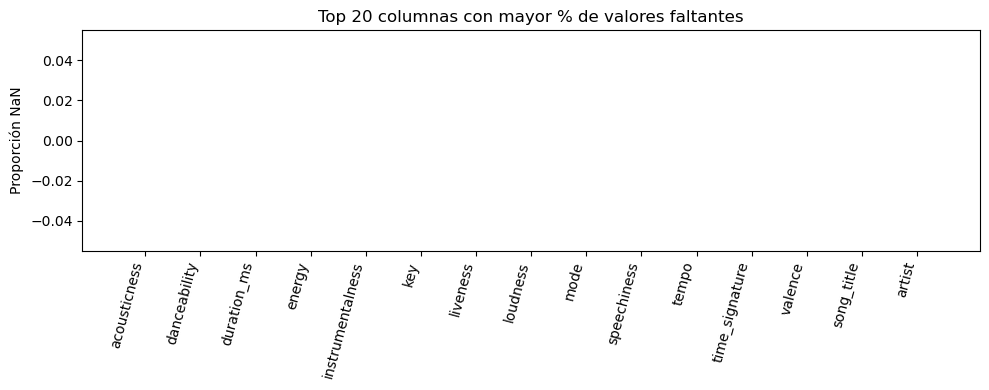

In [34]:
# Missing values
missing = X.isna().mean().sort_values(ascending=False)
print("\n % Missing por columna (top)")
display(missing.head(20))

plt.figure(figsize=(10, 4))
plt.bar(missing.index[:20].astype(str), missing.values[:20])
plt.xticks(rotation=75, ha="right")
plt.title("Top 20 columnas con mayor % de valores faltantes")
plt.ylabel("Proporción NaN")
plt.tight_layout()
plt.show()

### No se observan valores faltantes

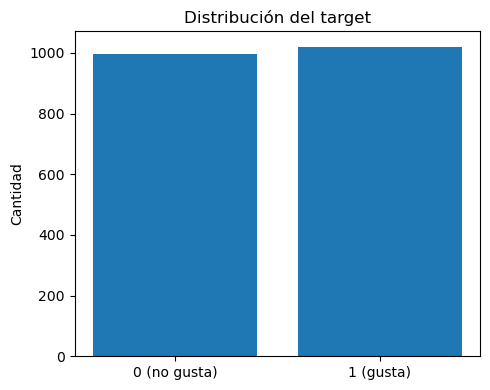

In [35]:
Y_target = df_spotify["target"]
counts = pd.Series(Y_target).value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(["0 (no gusta)", "1 (gusta)"], counts.values)
plt.title("Distribución del target")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

### Se observa dataset cuasi-balanceado

In [36]:
print("Proporción positiva (gusta):", counts.get(1, 0) / counts.sum())
print("Proporción negativa (no_gusta):", counts.get(0, 1) / counts.sum())

Proporción positiva (gusta): 0.5057015369360436
Proporción negativa (no_gusta): 0.49429846306395636


In [37]:
# Separar numéricos y categóricos
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNum cols:", len(num_cols), " | Cat cols:", len(cat_cols))


Num cols: 13  | Cat cols: 2


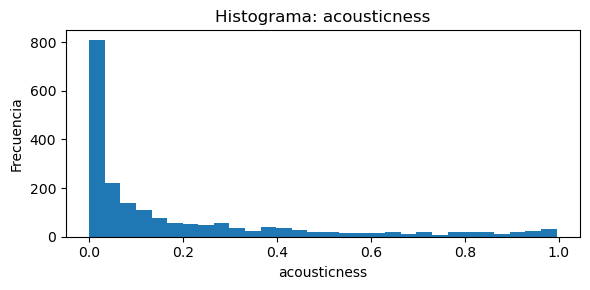

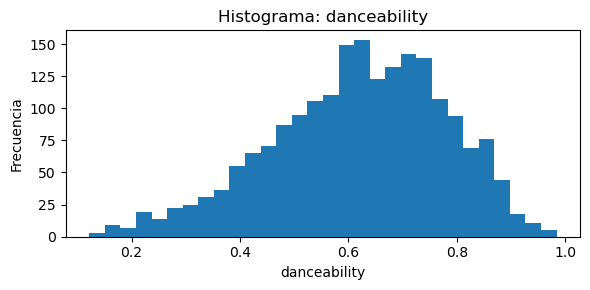

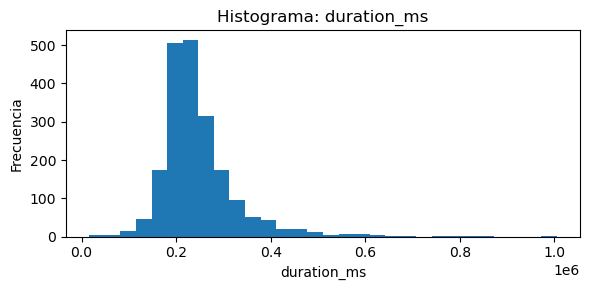

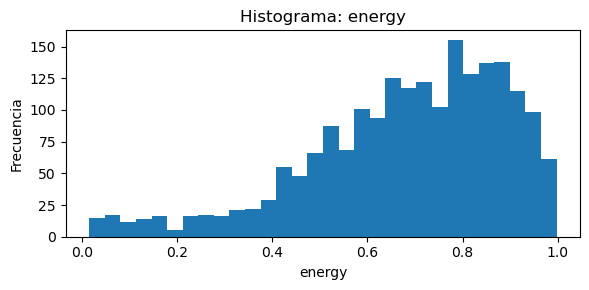

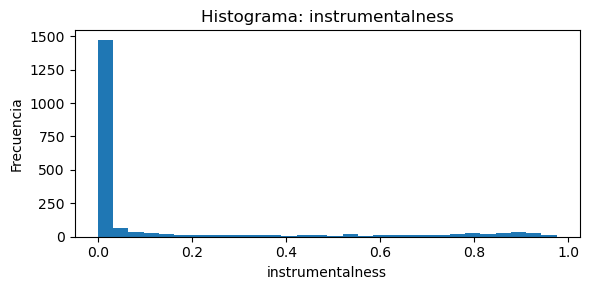

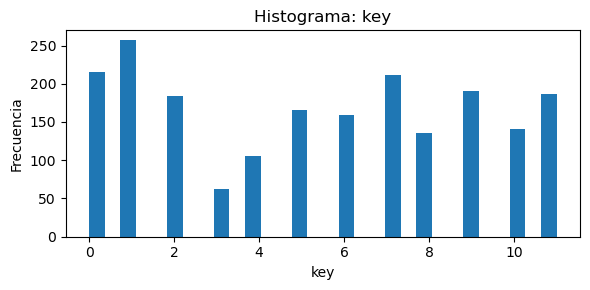

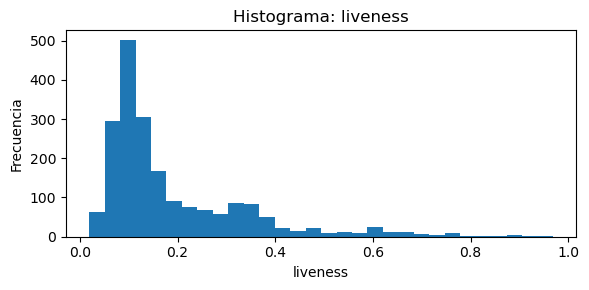

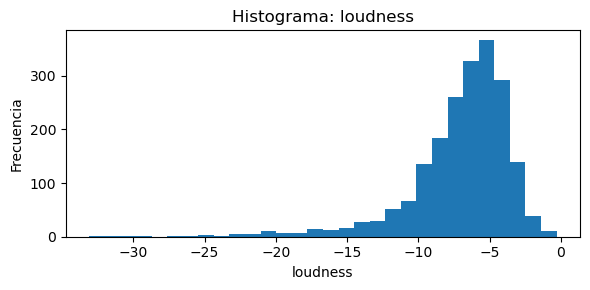

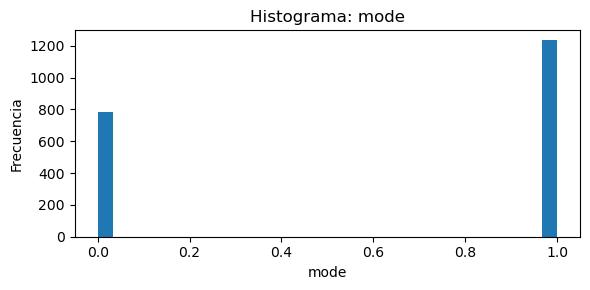

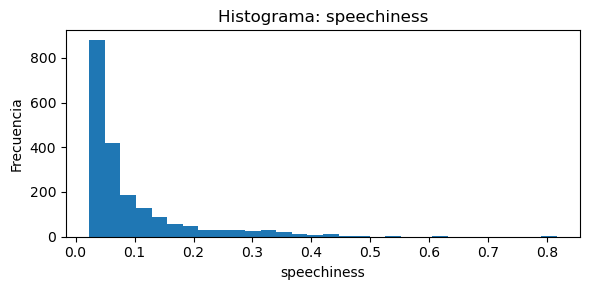

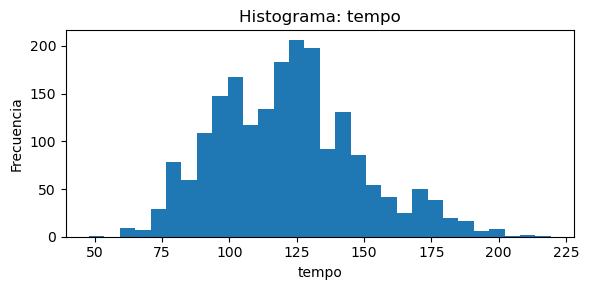

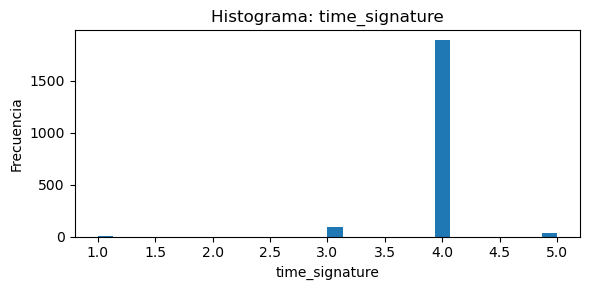

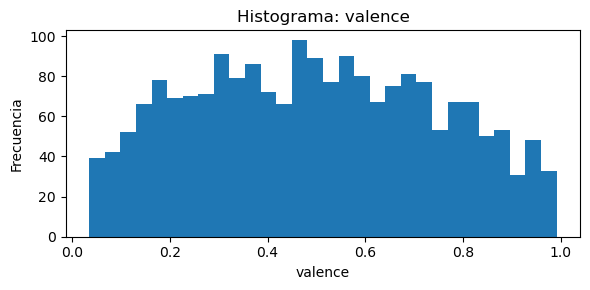

In [38]:
# Histogramas de numéricos (top 13)
top_num = num_cols[:13]
if len(top_num) > 0:
    for col in top_num:
        plt.figure(figsize=(6, 3))
        s = X[col].dropna()
        plt.hist(s, bins=30)
        plt.title(f"Histograma: {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

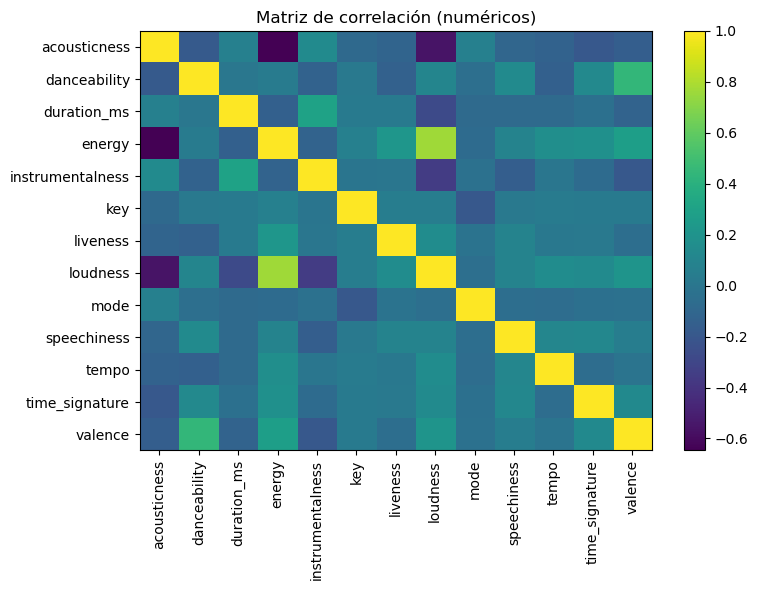

In [39]:
# Correlación (numéricos)
if len(num_cols) >= 2:
    corr = X[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    plt.imshow(corr.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Matriz de correlación (numéricos)")
    plt.tight_layout()
    plt.show()

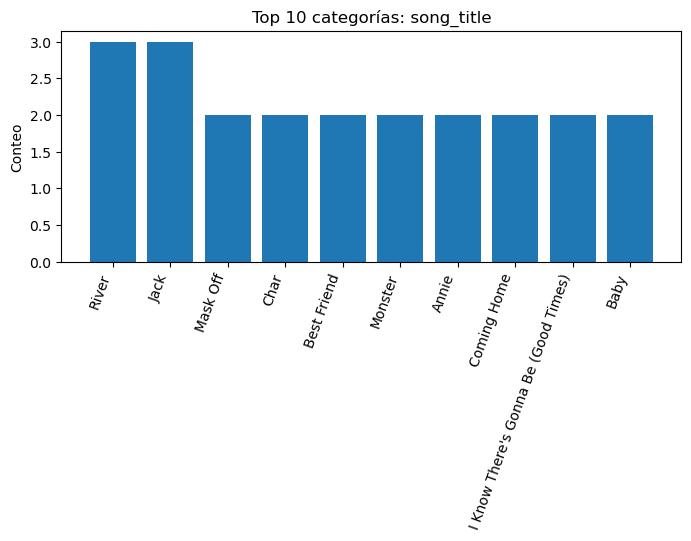

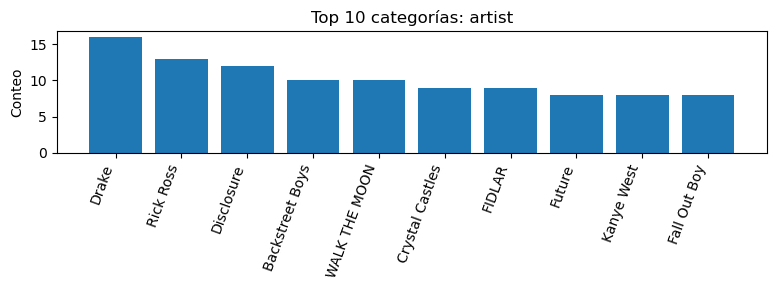

In [40]:
# Categóricos: top valores (hasta 2 columnas)
for col in cat_cols[:2]:
    vc = X[col].astype(str).value_counts().head(10)
    plt.figure(figsize=(8, 3))
    plt.bar(vc.index.astype(str), vc.values)
    plt.xticks(rotation=70, ha="right")
    plt.title(f"Top 10 categorías: {col}")
    plt.ylabel("Conteo")
    plt.tight_layout()
    plt.show()

## Vamos a filtrar por CALIDAD y REPRESENTATIVIDAD

### 1. Calidad (datos utilizables)

Se filtra por:

% de faltantes bajo

varianza > 0 (no constantes)

cantidad de valores únicos suficiente (si todo es el mismo número, no aporta)

In [41]:
def select_candidates(df, exclude=("target", "song_title", "artist"), min_non_null=0.9, min_unique=5):
    
    num_cols = df.select_dtypes(include=[np.number]).columns # Se seleccionan variables numéricas
    num_cols = [c for c in num_cols if c not in exclude]

    stats = []
    n = len(df)

    for c in num_cols:
        s = df[c]
        non_null_ratio = s.notna().mean()
        nunique = s.nunique(dropna=True)
        std = s.std()

        stats.append({
            "variable": c,
            "non_null_%": non_null_ratio * 100,
            "nunique": int(nunique),
            "std": float(std) if pd.notna(std) else np.nan,
            "zeros_%": float((s.dropna().eq(0).mean() * 100)) if s.notna().any() else np.nan
        })

    meta = pd.DataFrame(stats).sort_values(["non_null_%", "std"], ascending=[False, False])

    # filtros de calidad
    candidates = meta[
        (meta["non_null_%"] >= min_non_null * 100) & # porcentaje mínimo de datos no nulos
        (meta["nunique"] >= min_unique) & ## cantidad mínima de valores distintos que debe tener una variable
        (meta["std"] > 0)
    ].copy()

    return meta, candidates

meta, candidates = select_candidates(df_spotify, min_non_null=0.85, min_unique=5)

print("Metadata de columnas numéricas")
display(meta)

print("Candidatas (por calidad)")
display(candidates)

Metadata de columnas numéricas


,variable,non_null_%,nunique,std,zeros_%
2,duration_ms,100.0,1921,81981.814219,0.000000
10,tempo,100.0,1919,26.685604,0.000000
7,loudness,100.0,1808,3.761684,0.000000
5,key,100.0,12,3.648240,10.708974
8,mode,100.0,2,0.487347,38.770451
4,instrumentalness,100.0,1107,0.273162,34.357957
0,acousticness,100.0,1394,0.259989,0.000000
11,time_signature,100.0,4,0.255853,0.000000
12,valence,100.0,853,0.247195,0.000000
3,energy,100.0,719,0.210273,0.000000


Candidatas (por calidad)


,variable,non_null_%,nunique,std,zeros_%
2,duration_ms,100.0,1921,81981.814219,0.000000
10,tempo,100.0,1919,26.685604,0.000000
7,loudness,100.0,1808,3.761684,0.000000
5,key,100.0,12,3.648240,10.708974
4,instrumentalness,100.0,1107,0.273162,34.357957
0,acousticness,100.0,1394,0.259989,0.000000
12,valence,100.0,853,0.247195,0.000000
3,energy,100.0,719,0.210273,0.000000
1,danceability,100.0,632,0.161029,0.000000
6,liveness,100.0,793,0.155453,0.000000


In [42]:
excluidas = [var for var in meta["variable"].to_list() if var not in candidates["variable"].to_list()]
print(f"Las variables excluidas en este primer paso son: {' - '.join(excluidas)}")

Las variables excluidas en este primer paso son: mode - time_signature


### Si una variable toma menos de 5 valores distintos, probablemente no aporta mucho al análisis continuo.

### (meta["std"] > 0) significa descartar variables sin variación, porque no aportan información analítica.

## 2. Representatividad

### Evitar redundancia

Muchas variables son casi lo mismo (altamente correlacionadas).

In [43]:
def reduce_by_correlation(df, cols, threshold=0.95):
    
    X = df[cols].dropna() # Se eliminan columnas con valores faltantes
    
    corr = X.corr(numeric_only=True).abs() # Se calcula matriz de correlación solo de variables numéricas

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # Crea una matriz de unos del mismo tamaño que la matriz de correlación
    # luego se crea matriz triangular SUPERIOR con k=1 (excluye diagonal)
    # luego se convierten los 1 en True, y los 0 en False, se evita duplicar análisis de correlaciones
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    kept = [c for c in cols if c not in to_drop]

    return kept, to_drop, corr

cols = candidates["variable"].tolist()
kept, dropped, corr = reduce_by_correlation(df, cols, threshold=0.95)

print("Kept:", kept)
print("Dropped (redundantes):", dropped)
display(corr)

Kept: ['duration_ms', 'tempo', 'loudness', 'key', 'instrumentalness', 'acousticness', 'valence', 'energy', 'danceability', 'liveness', 'speechiness']
Dropped (redundantes): []


,duration_ms,tempo,loudness,key,instrumentalness,acousticness,valence,energy,danceability,liveness,speechiness
duration_ms,1.000000,0.076469,0.273798,0.023570,0.305403,0.071536,0.120030,0.144473,0.004695,0.023203,0.079562
tempo,0.076469,1.000000,0.156418,0.040301,0.000347,0.127596,0.014965,0.165721,0.143538,0.010558,0.111359
loudness,0.273798,0.156418,1.000000,0.050929,0.354625,0.562021,0.204968,0.762177,0.104362,0.156648,0.088844
key,0.023570,0.040301,0.050929,1.000000,0.009640,0.081037,0.032485,0.072886,0.022325,0.049739,0.019116
instrumentalness,0.305403,0.000347,0.354625,0.009640,1.000000,0.144397,0.194630,0.122890,0.130561,0.001063,0.155349
acousticness,0.071536,0.127596,0.562021,0.081037,0.144397,1.000000,0.152227,0.646319,0.179894,0.117126,0.099893
valence,0.120030,0.014965,0.204968,0.032485,0.194630,0.152227,1.000000,0.278383,0.442061,0.053011,0.054419
energy,0.144473,0.165721,0.762177,0.072886,0.122890,0.646319,0.278383,1.000000,0.038557,0.217435,0.093102
danceability,0.004695,0.143538,0.104362,0.022325,0.130561,0.179894,0.442061,0.038557,1.000000,0.132044,0.142661
liveness,0.023203,0.010558,0.156648,0.049739,0.001063,0.117126,0.053011,0.217435,0.132044,1.000000,0.092403


### Ninguna variable es eliminada por resultado de correlación

In [44]:
display(df_spotify.head())

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,target,song_title,artist
0,0.0102,0.833,204600,0.434,0.021900,2,0.1650,-8.795,1,0.4310,150.062,4.0,0.286,1,Mask Off,Future
1,0.1990,0.743,326933,0.359,0.006110,1,0.1370,-10.401,1,0.0794,160.083,4.0,0.588,1,Redbone,Childish Gambino
2,0.0344,0.838,185707,0.412,0.000234,2,0.1590,-7.148,1,0.2890,75.044,4.0,0.173,1,Xanny Family,Future
3,0.6040,0.494,199413,0.338,0.510000,5,0.0922,-15.236,1,0.0261,86.468,4.0,0.230,1,Master Of None,Beach House
4,0.1800,0.678,392893,0.561,0.512000,5,0.4390,-11.648,0,0.0694,174.004,4.0,0.904,1,Parallel Lines,Junior Boys


In [45]:
df_final = df_spotify.copy()
df_final = df_final.loc[:, ~df_final.columns.isin(["mode", "time_signature", "song_title", "artist"])]

La variable **song_title** no generaliza a canciones nuevas, se elimina

Si bien a las personas les gusta los artistas y el gusto musical es altamente dependiente del autor; para un modelo de clasificación no podemos suponer que le van a gustar todas las de ese autor en particular, sería introducir overfitting. Selimina la variable **artist**

In [46]:
Y_df = df_final[["target"]]
X_df = df_final.drop(columns=["target"])

In [47]:
# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_df, Y_df,
    test_size=0.15,
    random_state=42,
    stratify=Y_df
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1714, 11) Test: (303, 11)


In [48]:
scalers = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler()
}

In [49]:
results = []

for name, scaler in scalers.items():

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler)
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, [column for column in X_df.columns]),
        ],
        remainder="drop"
    )

    knn = KNeighborsClassifier(n_neighbors=10)

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("knn", knn)
    ])

    scores = cross_val_score(
        model,
        X_df, Y_df,
        cv=10,
        scoring="f1"
    )

    results.append({
        "scaler": name,
        "f1_mean": scores.mean(),
        "f1_std": scores.std()
    })

results_df = pd.DataFrame(results)
results_df

,scaler,f1_mean,f1_std
0,standard,0.649127,0.043344
1,minmax,0.606684,0.062697
2,robust,0.650772,0.059434


### Comparación de métodos de normalización

Se compararon distintos métodos dnormalizaciónndo (StandardScaler, MinMaxScaler y RobustScaler) utilizando validación cruzada y evaluando el desempeño mediante el F1-score.

Los resultados muestran que MinMaxScaler presenta el peor desempeño promedio y la mayor variabilidad, lo que sugiere una alta sensibilidaoutliersemos. En cambio, StandardScaler y RobustScaler obtienen valores de F1-score muy similares en promedio.

Si bien RobustScaler alcanza el F1-score medio más alto, la diferencia respecto a StandardScaler no resulta significativa y presenta una mayor variabilidad entre folds. Por este motivo, se selecciona StandardScaler como método de normalización, priorizando la estabilidad del clasificador sin pérdida apreciable de desempeño.


In [50]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, [column for column in X_df.columns]),
    ],
    remainder="drop"
)

knn = KNeighborsClassifier()

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", knn)
])

In [51]:
# BASELINE RÁPIDO (sin GridSearch)
model_baseline = model.set_params(knn__n_neighbors=10, knn__weights="uniform", knn__metric="minkowski")

model_baseline.fit(X_train, y_train)
y_pred = model_baseline.predict(X_test)

print("\n=== BASELINE KNN (k=10) ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1       :", f1_score(y_test, y_pred, zero_division=0))
print("\nReporte:\n", classification_report(y_test, y_pred, digits=4))


=== BASELINE KNN (k=10) ===
Accuracy : 0.7293729372937293
Precision: 0.808695652173913
Recall   : 0.6078431372549019
F1       : 0.6940298507462687

Reporte:
               precision    recall  f1-score   support

           0     0.6809    0.8533    0.7574       150
           1     0.8087    0.6078    0.6940       153

    accuracy                         0.7294       303
   macro avg     0.7448    0.7306    0.7257       303
weighted avg     0.7454    0.7294    0.7254       303



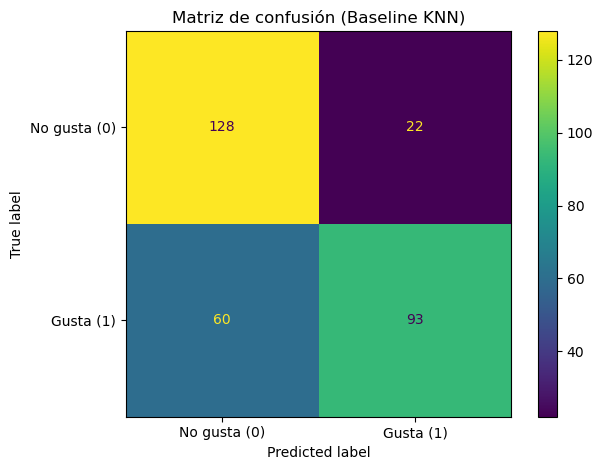

In [52]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No gusta (0)", "Gusta (1)"])
disp.plot()
plt.title("Matriz de confusión (Baseline KNN)")
plt.tight_layout()
plt.show()

AUC: 0.8123093681917212


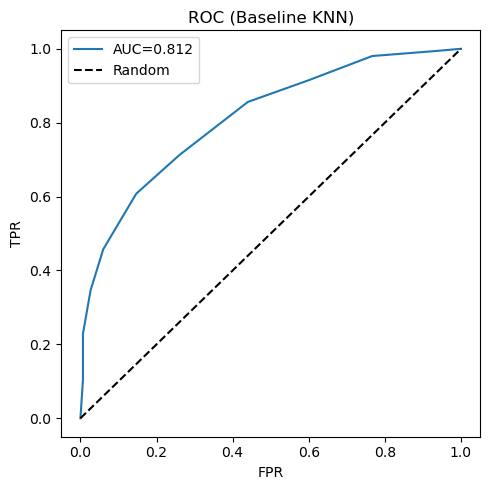

In [53]:
# ROC/AUC (si predict_proba existe)
if hasattr(model_baseline.named_steps["knn"], "predict_proba"):
    
    y_score = model_baseline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_score)
    print("AUC:", auc)

    fpr, tpr, thr = roc_curve(y_test, y_score)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC (Baseline KNN)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [67]:
# VALIDACIÓN CRUZADA + GRIDSEARCHCV (KNN)
cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

param_grid = {
    "knn__n_neighbors": list(range(1, 52, 2)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["minkowski"],
    "knn__p": [1, 2],
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",        # binario (clase positiva=1)
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 15 folds for each of 104 candidates, totalling 1560 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ighbors=10))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['minkowski'], 'knn__n_neighbors': [1, 3, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [68]:
print("\nGRIDSEARCH RESULT")
print("Best params:", grid.best_params_)
print("Best CV F1 :", grid.best_score_)


GRIDSEARCH RESULT
Best params: {'knn__metric': 'minkowski', 'knn__n_neighbors': 7, 'knn__p': 2, 'knn__weights': 'distance'}
Best CV F1 : 0.6922904392107024


In [69]:
best_model = grid.best_estimator_

# Evaluación final en test
y_pred_best = best_model.predict(X_test)

In [60]:
print("\nTEST (Best Model)")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_best, zero_division=0))
print("F1       :", f1_score(y_test, y_pred_best, zero_division=0))
print("\nReporte:\n", classification_report(y_test, y_pred_best, digits=4))


TEST (Best Model)
Accuracy : 0.7029702970297029
Precision: 0.7441860465116279
Recall   : 0.6274509803921569
F1       : 0.6808510638297872

Reporte:
               precision    recall  f1-score   support

           0     0.6724    0.7800    0.7222       150
           1     0.7442    0.6275    0.6809       153

    accuracy                         0.7030       303
   macro avg     0.7083    0.7037    0.7015       303
weighted avg     0.7087    0.7030    0.7013       303



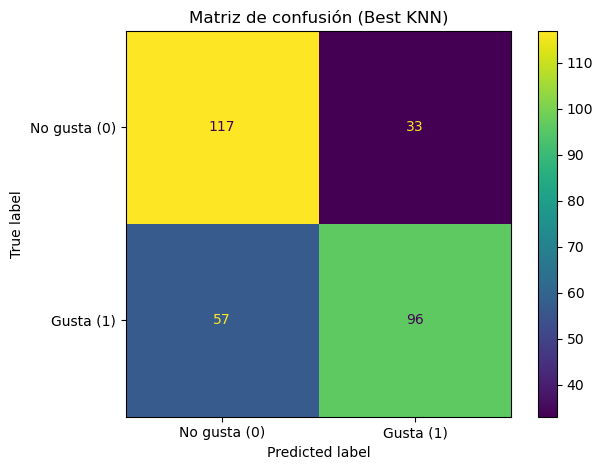

In [70]:
cm2 = confusion_matrix(y_test, y_pred_best, labels=[0, 1])
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["No gusta (0)", "Gusta (1)"])
disp2.plot()
plt.title("Matriz de confusión (Best KNN)")
plt.tight_layout()
plt.show()

AUC (best): 0.7981481481481482


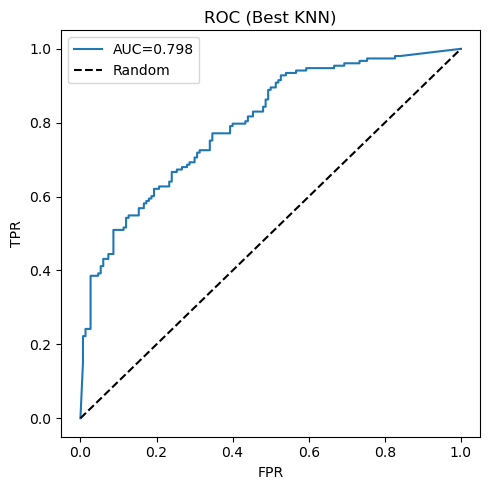

In [71]:
# ROC/AUC del mejor modelo
if hasattr(best_model.named_steps["knn"], "predict_proba"):
    y_score_best = best_model.predict_proba(X_test)[:, 1]
    auc_best = roc_auc_score(y_test, y_score_best)
    print("AUC (best):", auc_best)

    fpr, tpr, _ = roc_curve(y_test, y_score_best)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUC={auc_best:.3f}")
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC (Best KNN)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [73]:
# ESTABILIDAD DEL MODELO (CV SCORE DEL MEJOR)
cv_scores = cross_val_score(best_model, X_df, Y_df, cv=cv, scoring="f1", n_jobs=-1)
print("\nF1 CV scores:", cv_scores)
print("F1 CV mean ± std:", cv_scores.mean(), "±", cv_scores.std())


F1 CV scores: [0.75757576 0.70676692 0.65079365 0.76190476 0.672      0.61788618
 0.74015748 0.66115702 0.62809917 0.624      0.7107438  0.71666667
 0.765625   0.70866142 0.72      ]
F1 CV mean ± std: 0.6961358553822435 ± 0.0490978108234799


In [75]:
baseline_scores = cross_val_score(
    model_baseline, X_df, Y_df,
    cv=15, scoring="f1"
)

grid_scores = cross_val_score(
    grid.best_estimator_, X_df, Y_df,
    cv=15, scoring="f1"
)

print("Baseline CV F1:", baseline_scores.mean(), "±", baseline_scores.std())
print("Grid CV F1    :", grid_scores.mean(), "±", grid_scores.std())

Baseline CV F1: 0.6570173496161785 ± 0.05090674596615903
Grid CV F1    : 0.6816012288196261 ± 0.035294125213097466


### Selección del modelo final

Se comparó el desempeño del modelo base y del modelo optimizado mediante Grid Search utilizando validación cruzada estratificada.

Los resultados muestran que el modelo seleccionado por Grid Search alcanza un F1-score promedio superior (\(\approx 0.68\)) y una menor variabilidad entre folds en comparación con el modelo base, lo que indica una mayor estabilidad y capacidad de generalización.

Si bien el modelo base puede obtener mejores resultados en una partición específica de entrenamiento–test, el análisis por validación cruzada respalda la elección del modelo optimizado como solución inal.
